# MIND-Edge-Recommender — end-to-end
**Tiny multilingual news recommender: offline pretraining on MIND + xMIND, with a
NAS × precision study of flash / RAM / energy for the edge.**

This notebook is the single control surface for the whole project (A→Z). Long
code lives in `src/*.py`; every cell here is short and preceded by a note, and
every knob is set from `config.yaml` / this notebook.

**Map:** setup → data → teacher → student/distillation → NAS (3 arms) →
train → precision sweep → baseline → ablation → multilingual → latency/energy →
export → plots. Architecture axis: NAS → Micro-NAS → binarized-Micro-NAS.
Precision axis: FP32 → INT8 → Binary. Targets: RTX 5070 → Raspberry Pi 5 → STM32H7.

## 1. Setup
Add the repo root to the path (works whether the kernel starts in the repo root
or in `notebooks/`), import the modules, and load the central config.

In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
root = root if (root / "src").exists() else root.parent
sys.path.insert(0, str(root))
import pandas as pd, torch
from src.config import load_config
from src import experiment, export, measure_energy, data_mind, data_xmind
cfg = load_config()
print("device:", "cuda" if torch.cuda.is_available() else "cpu", "| artifacts:", cfg["paths"]["artifacts_dir"])

C:\Projects\PhD\MIND\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda | artifacts: C:\Projects\PhD\MIND\artifacts


## 2. Configuration (the control surface)
Every experiment knob lives in `config.yaml` and can be overridden here in memory
before running anything. The key groups:

In [2]:
{k: cfg[k] for k in ["data", "teacher", "student", "nas", "quant", "train"]}

{'data': {'mind_size': 'small',
  'xmind_langs': ['zho',
   'fin',
   'grn',
   'hat',
   'ind',
   'jpn',
   'kat',
   'ron',
   'som',
   'swh',
   'tam',
   'tha',
   'tur',
   'vie'],
  'max_history': 50,
  'max_title_bytes': 128,
  'neg_ratio': 4},
 'teacher': {'model': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
  'embed_dim': 384,
  'batch_size': 256},
 'student': {'type': 'byte_cnn',
  'byte_embed_dim': 64,
  'channels': 128,
  'depth': 3,
  'out_dim': 384,
  'matryoshka_dim': 64},
 'nas': {'method': 'evolutionary',
  'search_space': {'channels': [32, 64, 96, 128, 192, 256],
   'depth': [1, 2, 3, 4, 5],
   'out_dim': [64, 128, 256, 384]},
  'population': 50,
  'generations': 20,
  'constraints': {'flash_kb': 256, 'ram_kb': 128, 'max_macs': 2000000}},
 'quant': {'int8': {'method': 'qat'}, 'binary': {'keep_first_last_fp': True}},
 'train': {'device': 'cuda',
  'epochs': 10,
  'batch_size': 64,
  'lr': 0.0001,
  'distill_epochs': 15,
  'distill_lr': 0.001}}

## 3. Run scale
`QUICK=True` runs a fast smoke pass (few epochs / small NAS / capped impressions)
so the whole notebook executes in minutes. Set `QUICK=False` for the full
paper-grade run. This single switch drives every heavy cell below.

In [3]:
QUICK = True
if QUICK:
    cfg["train"]["distill_epochs"], cfg["train"]["epochs"] = 2, 2
    NAS = dict(generations=3, population=8, n_train=8000, n_val=2000, distill_epochs=1)
    EVAL_IMPR, QAT, TRAIN_IMPR, DISTILL_EP = 1000, 0, 2000, 2
else:
    NAS = dict(generations=cfg["nas"]["generations"], population=cfg["nas"]["population"])
    EVAL_IMPR, QAT, TRAIN_IMPR, DISTILL_EP = None, 2, None, 15
QUICK

True

## 4. Datasets
MIND + xMIND are pre-downloaded (`python -m src.download` to refresh). Show the
SHA256 manifest size and basic statistics.

In [4]:
import json
manifest = json.load(open(pathlib.Path(cfg["paths"]["data_dir"]) / "manifest.json"))
news = data_mind.read_news(cfg, "train")
print(len(manifest), "files SHA256-pinned")
print("MIND train: news", len(news), "| categories", len(data_mind.category_vocab(news)))
print("xMIND languages:", data_xmind.available_langs(cfg))

2 files SHA256-pinned
MIND train: news 51282 | categories 17
xMIND languages: ['zho', 'fin', 'grn', 'hat', 'ind', 'jpn', 'kat', 'ron', 'som', 'swh', 'tam', 'tha', 'tur', 'vie']


## 5. One article, many languages
xMIND translates the same article; behaviours stay English. Here is one news id
shown in a few languages (the byte-level model will encode all of them).

In [5]:
nid = next(iter(news))
print("[en ]", news[nid]["title"])
for lang in ["ron", "jpn", "zho"]:
    print(f"[{lang}]", data_xmind.read_xmind_text(cfg, lang, "train").get(nid, {}).get("title", "-"))

[en ] The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By


[ron] Brandurile pe care Regina Elisabeta, Prinţul Charles şi Prinţul Philip le jură


[jpn] エリザベス 女王,チャールズ 王子,フィリップ 王子 が 誓っ て いる ブランド
[zho] 伊麗莎白女王,查爾斯王子和菲利普王子所宣誓的品牌


## 6. Teacher anchors
Compute (and cache) the frozen multilingual teacher's English-title embeddings —
the shared distillation targets for all 14 languages.

In [6]:
experiment.ensure_anchors(cfg)

## 7. Distil the byte-CNN student
Distil the language-agnostic byte-level student to the teacher anchors.

In [7]:
student_encoder = experiment.distill(cfg)

[distill] epoch 1/2  loss=0.6829


[distill] epoch 2/2  loss=0.5876
[distill] saved -> C:\Projects\PhD\MIND\artifacts\student.pt


## 8. Sanity: does the student align languages?
A title and its translation should map to nearby vectors (high cosine).

In [8]:
import torch.nn.functional as F
from src.student import text_to_bytes
L = cfg["data"]["max_title_bytes"]; enc_cpu = student_encoder.cpu()
def emb(t):
    with torch.no_grad():
        return F.normalize(enc_cpu(torch.tensor([text_to_bytes(t, L)])), dim=-1)[0]
dev_en = data_mind.read_news(cfg, "dev"); dev_ro = data_xmind.localized_news(cfg, "ron", "dev")
k = next(iter(dev_en))
print("cosine(en, ron):", round(F.cosine_similarity(emb(dev_en[k]["title"]), emb(dev_ro[k]["title"]), dim=0).item(), 3))

cosine(en, ron): 0.798


## 9. Architecture search (3 arms)
One search space; three arms differ by precision + constraints: `nas` (FP32,
loose), `micro_nas` (INT8, hard MCU budget), `binarized_micro_nas` (Binary).
Fitness = distillation quality under footprint feasibility.

In [9]:
arms = experiment.search_arms(cfg, **NAS)
best = {arm: experiment.best_arch(res) for arm, res in arms.items()}
pd.DataFrame([{"arm": a, **best[a], "quality": arms[a][0]["quality"],
               "size_kb": arms[a][0]["size_kb"], "feasible": arms[a][0]["feasible"]} for a in arms])

[nas:nas] gen 1/3 best_q=0.1884 size_kb=520.75 feasible=12/12


[nas:nas] gen 2/3 best_q=0.2020 size_kb=551.75 feasible=17/17


[nas:nas] gen 3/3 best_q=0.2020 size_kb=551.75 feasible=20/20


[nas:micro_nas] gen 1/3 best_q=0.1109 size_kb=134.44 feasible=6/11


[nas:micro_nas] gen 2/3 best_q=0.1544 size_kb=240.37 feasible=9/14


[nas:micro_nas] gen 3/3 best_q=0.1544 size_kb=240.37 feasible=11/17


[nas:binarized_micro_nas] gen 1/3 best_q=0.1192 size_kb=176.39 feasible=7/11


[nas:binarized_micro_nas] gen 2/3 best_q=0.1257 size_kb=239.78 feasible=9/14
[nas:binarized_micro_nas] gen 3/3 best_q=0.1257 size_kb=239.78 feasible=10/15


,arm,channels,depth,out_dim,quality,size_kb,feasible
0,nas,192,1,384,0.2020,551.75,True
1,micro_nas,192,2,64,0.1544,240.37,True
2,binarized_micro_nas,192,4,128,0.1257,239.78,True


## 10. Train a recommender per arm
Train the end-to-end recommender (news encoder = each arm's best architecture).

In [10]:
models = {arm: experiment.train_for_arch(cfg, best[arm], max_train_impressions=TRAIN_IMPR)
          for arm in best}

[rec] epoch 1  loss=1.6685


[rec] epoch 2  loss=1.5575


[rec] epoch 1  loss=1.5919


[rec] epoch 2  loss=1.5369


[rec] epoch 1  loss=1.6011


[rec] epoch 2  loss=1.5005


## 11. Precision sweep → results matrix
Evaluate each model at FP32 / INT8 / Binary (PTQ + optional QAT) with ranking
metrics and footprint (size, RAM, MACs, energy).

In [11]:
rows = []
for arm in models:
    rows += experiment.precision_sweep(cfg, models[arm], best[arm], arm, qat_epochs=QAT, max_eval=EVAL_IMPR)
matrix = experiment.save_matrix(cfg, rows); matrix

,arm,precision,channels,depth,out_dim,auc,mrr,ndcg@10,size_kb,ram_kb,macs,energy_uj
0,nas,fp32,192,1,384,0.5009,0.2406,0.2847,551.75,96.0,6537216,30.0712
1,nas,int8,192,1,384,0.5011,0.2408,0.2851,442.06,24.0,1744896,6.0053
2,nas,binary,192,1,384,0.5159,0.2527,0.2985,410.07,24.0,1744896,5.9023
3,micro_nas,fp32,192,2,64,0.5262,0.2541,0.2967,459.75,96.0,11366400,52.2854
4,micro_nas,int8,192,2,64,0.5254,0.2531,0.2961,240.37,24.0,1781760,3.2423
5,micro_nas,binary,192,2,64,0.5170,0.2564,0.2939,176.39,24.0,1781760,2.9898
6,binarized_micro_nas,fp32,192,4,128,0.4814,0.2492,0.2905,806.50,96.0,21159936,97.3357
7,binarized_micro_nas,int8,192,4,128,0.4819,0.2490,0.2895,367.75,24.0,1990656,2.8470
8,binarized_micro_nas,binary,192,4,128,0.5216,0.2469,0.2875,239.78,24.0,1990656,2.5253


## 12. NRMS baseline (FP32 ceiling)
Reproduced NRMS on the **same** MINDsmall-dev split (like-for-like). External
reference: published MINDlarge-test NRMS AUC 0.6776.

In [12]:
experiment.baseline_row(cfg, epochs=cfg["train"]["epochs"], max_eval=EVAL_IMPR)

[nrms] epoch 1 loss=1.4510


[nrms] epoch 2 loss=1.3654


{'arm': 'NRMS (baseline)',
 'precision': 'fp32',
 'auc': 0.5832,
 'mrr': 0.3067,
 'ndcg@10': 0.3454}

## 13. Ablation: does distillation help?
Same Micro-NAS architecture, news encoder trained from scratch vs initialised
from the distilled student then fine-tuned.

In [13]:
abl = experiment.run_ablation(cfg, distill_epochs=DISTILL_EP,
                             train_epochs=cfg["train"]["epochs"], max_train_impressions=TRAIN_IMPR)
pd.DataFrame([{"init": "scratch", **abl["scratch"]},
              {"init": "distilled", **abl["distilled_init"]}])[["init", "auc", "mrr", "ndcg@10"]]

[rec] epoch 1  loss=2.3936


[rec] epoch 2  loss=1.6236


[rec] epoch 1  loss=1.5848


[rec] epoch 2  loss=1.5414


,init,auc,mrr,ndcg@10
0,scratch,0.5184,0.2516,0.2969
1,distilled,0.5783,0.2988,0.3434


## 14. Multilingual evaluation (all 14 languages)
Cross-lingual transfer: identical English impressions, news text swapped per
language through the SAME byte-level model.

In [14]:
deploy = models["micro_nas"]
experiment.eval_languages(cfg, deploy, max_impressions=EVAL_IMPR or 2000)

,lang,auc,mrr,ndcg@5,ndcg@10
0,en,0.5262,0.2541,0.2327,0.2967
1,zho,0.5092,0.2676,0.2420,0.3011
2,fin,0.5524,0.2990,0.2762,0.3326
3,grn,0.4834,0.2377,0.2174,0.2732
4,hat,0.5471,0.2705,0.2435,0.3123
5,ind,0.4993,0.2405,0.2136,0.2803
6,jpn,0.4683,0.2159,0.1906,0.2565
7,kat,0.5367,0.3005,0.2705,0.3316
8,ron,0.5121,0.2399,0.2205,0.2842
9,som,0.4429,0.2117,0.1875,0.2533


## 15. Measured latency & energy (laptop)
GPU latency + NVML energy; ONNX CPU latency uses the same path that runs on the
Pi 5 aarch64 wheel (pair with an INA219 for real Pi/STM32 power).

In [15]:
ex = torch.zeros(8, cfg["data"]["max_title_bytes"], dtype=torch.long)
print("GPU latency ms:", round(measure_energy.latency_torch(deploy.news_encoder, ex), 4))
print("Energy:", measure_energy.energy_nvml(deploy.news_encoder, ex, n=200))

GPU latency ms: 0.4349
Energy: {'available': True, 'avg_power_w': 15.63, 'idle_w': 15.63, 'energy_mj_per_inf': np.float64(-0.0), 'latency_ms': 0.4383}


## 16. Export the deployment model
ONNX content encoder + cold-start `topicWeights` prior, mapped to the app's
`edgeml_model_state_v1` schema (Micro-NAS / INT8 sweet spot).

In [16]:
langs = ["en"] + data_xmind.available_langs(cfg)
print(export.export_artifacts(cfg, deploy.news_encoder.cpu(), langs))

C:\Projects\PhD\MIND\src\export.py:36: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


W0623 16:58:15.199000 10424 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


C:\Projects\PhD\MIND\artifacts\edgeml_micro_nas_int8.json


## 17. Export every arm + comparison manifest
Export one ONNX per arm and a `models_manifest.json` so the app can pick a
trade-off. (INT8/Binary are *simulated* for measurement; the deployed ONNX is the
FP32 graph that the target runtime — e.g. X-CUBE-AI — quantizes itself.)

In [17]:
arm_label = {"nas": "nas", "micro_nas": "micro_nas", "binarized_micro_nas": "bin_unas"}
to_export = {(arm_label[a], "fp32"): m.news_encoder.cpu() for a, m in models.items()}
print(export.export_all(cfg, to_export, langs))

C:\Projects\PhD\MIND\src\export.py:36: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
C:\Projects\PhD\MIND\src\export.py:36: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
C:\Projects\PhD\MIND\src\export.py:36: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ByteCNNEncoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
C:\Projects\PhD\MIND\artifacts\models_manifest.json


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


## 18. Pareto: accuracy vs footprint and energy

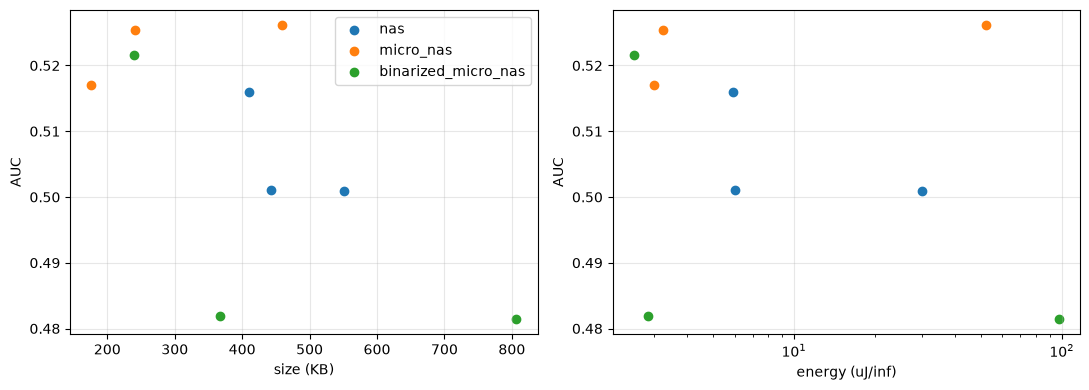

In [18]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for arm in matrix["arm"].unique():
    s = matrix[matrix["arm"] == arm]
    ax[0].scatter(s["size_kb"], s["auc"], label=arm); ax[1].scatter(s["energy_uj"], s["auc"], label=arm)
ax[0].set(xlabel="size (KB)", ylabel="AUC"); ax[1].set(xlabel="energy (uJ/inf)", ylabel="AUC")
ax[1].set_xscale("log"); ax[0].legend(); [a.grid(alpha=.3) for a in ax]; plt.tight_layout(); plt.show()

## 19. Reproduce the paper's headline numbers
Load the cached full-run summary (`scripts/run_full.py`) — the numbers reported
in `paper/`.

In [19]:
p = pathlib.Path(cfg["paths"]["artifacts_dir"]) / "results_summary.json"
if p.exists():
    s = json.load(open(p))
    print("best archs:", s["best_arch"]); print("NRMS baseline:", s["baseline"])
    display(pd.DataFrame(s["matrix"])[["arm", "precision", "auc", "size_kb", "energy_uj"]])
else:
    print("Run `python -m scripts.run_full` for the full paper-grade numbers.")

best archs: {'nas': {'channels': 256, 'depth': 4, 'out_dim': 384}, 'micro_nas': {'channels': 64, 'depth': 5, 'out_dim': 384}, 'binarized_micro_nas': {'channels': 96, 'depth': 2, 'out_dim': 384}}
NRMS baseline: {'arm': 'NRMS (baseline)', 'precision': 'fp32', 'auc': 0.6074, 'mrr': 0.3218, 'ndcg@10': 0.3635}


,arm,precision,auc,size_kb,energy_uj
0,nas,fp32,0.6327,1566.75,168.6700
1,nas,int8,0.6471,789.75,4.6518
2,nas,binary,0.5878,563.12,4.2511
3,micro_nas,fp32,0.6045,266.75,15.9023
4,micro_nas,int8,0.6100,203.94,2.3006
5,micro_nas,binary,0.5210,185.62,2.2507
6,binarized_micro_nas,fp32,0.5934,311.38,15.4313
7,binarized_micro_nas,int8,0.6009,255.69,3.2790
8,binarized_micro_nas,binary,0.5460,239.45,3.2300


## 20. Conclusions
- One byte-level model fits the STM32H7 budget and serves all 14 languages.
- INT8 Micro-NAS is the measured sweet spot; Binary is footprint-motivated.
- Distillation makes the tiny model competitive (see the ablation).
- Artifacts in `artifacts/`; the write-up in `paper/`.